# Week 6

## 230968334 - Ashrith Reddy - DSE B - 48

Exercise 1: Hill-Climbing Search for Feature Selection in Predictive Modeling
Problem Statement: You are given a dataset (select a random dataset) with multiple input
features and a target variable. Each state represents a subset of selected features. The goal is
to find a feature subset that maximizes model accuracy.
State Representation
 A binary vector indicating whether a feature is selected (1) or not (0)
Initial State
 A randomly generated feature subset
Neighbor Generation
 Flip one bit (add/remove one feature)
Evaluation Function
 Cross-validation accuracy of a simple classifier (e.g., Logistic Regression)
Algorithm Implementation
 Implement steepest-ascent hill climbing
 Stop when no neighbor improves the current solution
Experimentation
 Run the algorithm multiple times with different random initial states

In [1]:
import numpy as np
import random
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

n_features = X.shape[1]

# Evaluation function
def evaluate(state):
    selected_features = [i for i in range(len(state)) if state[i] == 1]
    
    if len(selected_features) == 0:
        return 0
    
    X_subset = X[:, selected_features]
    
    model = LogisticRegression(max_iter=5000)
    score = cross_val_score(model, X_subset, y, cv=5).mean()
    
    return score

# Generate neighbors by flipping one bit
def get_neighbors(state):
    neighbors = []
    
    for i in range(len(state)):
        new_state = state.copy()
        new_state[i] = 1 - new_state[i]  # flip bit
        neighbors.append(new_state)
    
    return neighbors

# Hill Climbing (Steepest Ascent)
def hill_climbing():
    # Random initial state
    current_state = [random.choice([0, 1]) for _ in range(n_features)]
    current_score = evaluate(current_state)
    
    while True:
        neighbors = get_neighbors(current_state)
        
        best_neighbor = None
        best_score = current_score
        
        # Find best neighbor
        for neighbor in neighbors:
            score = evaluate(neighbor)
            
            if score > best_score:
                best_score = score
                best_neighbor = neighbor
        
        # Stop if no improvement
        if best_neighbor is None:
            break
        
        current_state = best_neighbor
        current_score = best_score
    
    return current_state, current_score

# Run multiple experiments
num_runs = 5
results = []

for i in range(num_runs):
    best_state, best_score = hill_climbing()
    selected_features = sum(best_state)
    
    print(f"Run {i+1}: Accuracy = {best_score:.4f}, Features selected = {selected_features}")
    results.append(best_score)

print("\nAverage Accuracy:", np.mean(results))

Run 1: Accuracy = 0.9578, Features selected = 18
Run 2: Accuracy = 0.9543, Features selected = 16
Run 3: Accuracy = 0.9561, Features selected = 9
Run 4: Accuracy = 0.9561, Features selected = 14
Run 5: Accuracy = 0.9561, Features selected = 18

Average Accuracy: 0.956078248719143


Exercise 2: Simulated Annealing for Vehicle Routing Optimization
Problem Statement: A delivery vehicle must visit a set of locations and return to the depot.
The order of visiting locations affects the total travel cost. Each state represents a permutation
of delivery locations.
State Representation
 A sequence representing the visiting order of delivery points
Initial State
 A random permutation of locations
Neighbor Generation
 Swap two locations in the route
Cost Function
 Total travel distance of the route
Simulated Annealing Implementation
 Implement SA using:
o Temperature schedule T(t)
o Acceptance probability:
P=e
−Δ E/ T

Best Route: [0, 5, 7, 4, 8, 9, 3, 2, 1, 6, 0]
Minimum Distance: 325.0736521295076


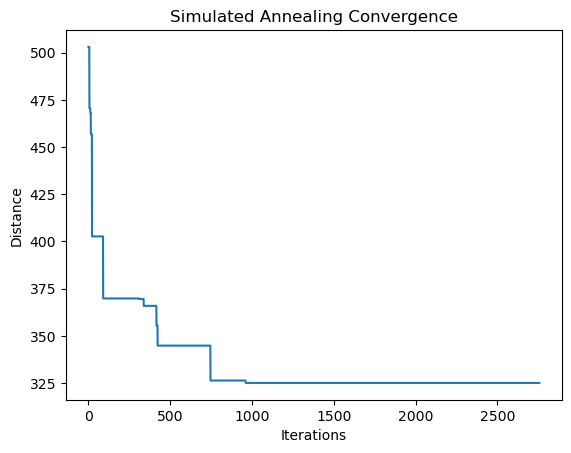

In [2]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

# Generate random locations (including depot at index 0)
num_locations = 10
locations = np.random.rand(num_locations, 2) * 100  # (x, y) coordinates

# Distance function
def distance(a, b):
    return np.linalg.norm(a - b)

# Total route cost
def total_distance(route):
    dist = 0
    for i in range(len(route) - 1):
        dist += distance(locations[route[i]], locations[route[i+1]])
    return dist

# Generate initial random route
def initial_state():
    route = list(range(1, num_locations))
    random.shuffle(route)
    return [0] + route + [0]

# Generate neighbor by swapping two cities
def get_neighbor(route):
    new_route = route[1:-1].copy()
    i, j = random.sample(range(len(new_route)), 2)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return [0] + new_route + [0]

# Simulated Annealing
def simulated_annealing():
    current = initial_state()
    current_cost = total_distance(current)
    
    best = current
    best_cost = current_cost
    
    T = 1000  # initial temperature
    T_min = 1e-3
    alpha = 0.995  # cooling rate
    
    costs = []
    
    while T > T_min:
        neighbor = get_neighbor(current)
        neighbor_cost = total_distance(neighbor)
        
        delta = neighbor_cost - current_cost
        
        if delta < 0:
            current = neighbor
            current_cost = neighbor_cost
        else:
            prob = math.exp(-delta / T)
            if random.random() < prob:
                current = neighbor
                current_cost = neighbor_cost
        
        if current_cost < best_cost:
            best = current
            best_cost = current_cost
        
        costs.append(best_cost)
        T *= alpha
    
    return best, best_cost, costs

# Run algorithm
best_route, best_cost, cost_history = simulated_annealing()

print("Best Route:", best_route)
print("Minimum Distance:", best_cost)

# Plot convergence
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Distance")
plt.title("Simulated Annealing Convergence")
plt.show()

In [ ]:
Exercise 3 (Revised): Genetic Algorithm for Autonomous Drone Path Planning
Problem Statement: A drone must travel from a start location to a destination in a 2D
environment with obstacles. Each candidate solution represents a sequence of waypoints
defining a flight path. The goal is to evolve paths that minimize travel distance while
avoiding obstacles.
Chromosome Representation
 A fixed-length sequence of (x, y) waypoints
Initial Population
 Randomly generated feasible paths
Fitness Function
 Minimize:
o Total path length
o Obstacle collisions (high penalty)
Genetic Operators
 Selection: Tournament selection
 Crossover: One-point crossover on waypoint sequence
 Mutation: Random perturbation of waypoint coordinates
Constraints
 Waypoints must remain within map boundaries
 Paths intersecting obstacles are penalized
Termination Condition
 Fixed number of generations or convergence

In [3]:
import random
import math

# ==============================
# PARAMETERS
# ==============================
POP_SIZE = 50
NUM_WAYPOINTS = 5
GENERATIONS = 100
MUTATION_RATE = 0.2

X_MIN, X_MAX = 0, 100
Y_MIN, Y_MAX = 0, 100

START = (0, 0)
END = (100, 100)

# Obstacles: list of rectangles (x1, y1, x2, y2)
OBSTACLES = [
    (30, 30, 50, 50),
    (60, 60, 80, 80)
]

PENALTY = 1000

# ==============================
# HELPER FUNCTIONS
# ==============================

def distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


def path_length(path):
    total = 0
    for i in range(len(path) - 1):
        total += distance(path[i], path[i+1])
    return total


def inside_obstacle(point):
    x, y = point
    for (x1, y1, x2, y2) in OBSTACLES:
        if x1 <= x <= x2 and y1 <= y <= y2:
            return True
    return False


def collision_penalty(path):
    penalty = 0
    for point in path:
        if inside_obstacle(point):
            penalty += PENALTY
    return penalty


def fitness(path):
    length = path_length(path)
    penalty = collision_penalty(path)
    return 1 / (length + penalty + 1e-6)


# ==============================
# INITIALIZATION
# ==============================

def random_waypoint():
    return (
        random.uniform(X_MIN, X_MAX),
        random.uniform(Y_MIN, Y_MAX)
    )


def create_individual():
    path = [START]
    for _ in range(NUM_WAYPOINTS):
        path.append(random_waypoint())
    path.append(END)
    return path


def create_population():
    return [create_individual() for _ in range(POP_SIZE)]


# ==============================
# SELECTION (TOURNAMENT)
# ==============================

def tournament_selection(population):
    k = 3
    selected = random.sample(population, k)
    selected.sort(key=lambda x: fitness(x), reverse=True)
    return selected[0]


# ==============================
# CROSSOVER (ONE-POINT)
# ==============================

def crossover(parent1, parent2):
    point = random.randint(1, NUM_WAYPOINTS)

    child = [START]
    child += parent1[1:point+1]
    child += parent2[point+1:-1]
    child.append(END)

    return child


# ==============================
# MUTATION
# ==============================

def mutate(path):
    new_path = path[:]

    for i in range(1, len(path)-1):  # skip start & end
        if random.random() < MUTATION_RATE:
            dx = random.uniform(-5, 5)
            dy = random.uniform(-5, 5)

            x = min(max(path[i][0] + dx, X_MIN), X_MAX)
            y = min(max(path[i][1] + dy, Y_MIN), Y_MAX)

            new_path[i] = (x, y)

    return new_path


# ==============================
# MAIN GA LOOP
# ==============================

def genetic_algorithm():
    population = create_population()

    for gen in range(GENERATIONS):
        new_population = []

        for _ in range(POP_SIZE):
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            child = crossover(parent1, parent2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

        # Print best fitness every 10 generations
        if gen % 10 == 0:
            best = max(population, key=lambda x: fitness(x))
            print(f"Generation {gen}: Best fitness = {fitness(best):.6f}")

    best = max(population, key=lambda x: fitness(x))
    return best


# ==============================
# RUN
# ==============================

best_path = genetic_algorithm()

print("\nBest Path:")
for point in best_path:
    print(point)

Generation 0: Best fitness = 0.005945
Generation 10: Best fitness = 0.006865
Generation 20: Best fitness = 0.007067
Generation 30: Best fitness = 0.007071
Generation 40: Best fitness = 0.007071
Generation 50: Best fitness = 0.007071
Generation 60: Best fitness = 0.007071
Generation 70: Best fitness = 0.007071
Generation 80: Best fitness = 0.007071
Generation 90: Best fitness = 0.007071

Best Path:
(0, 0)
(9.448028845712589, 9.482578322758961)
(52.598928962312186, 52.44592043824953)
(86.36335144643894, 86.30761852913463)
(93.3997845456855, 93.17933954965254)
(100, 100)
(100, 100)
